# 🔍 Dilithium 부채널 공격: 단일 트레이스 정밀 분석

이 노트북은 모델의 성능을 단일 트레이스 관점에서 분석하여 문제의 원인을 파악합니다.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix

MODEL_PATH = 'dilithium_final_v4.keras'
DATASET_DIR = '../Dataset'
POI_PATH = 'poi_indices.npy'
MEAN_PATH = 'used_mean.npy'
STD_PATH = 'used_std.npy'

def get_hw(n):
    return bin(int(n) & 0xFFFFFFFF).count('1')

def moving_average(data, window_size=5):
    kernel = np.ones(window_size) / window_size
    if len(data.shape) == 1: return np.convolve(data, kernel, mode='same')
    return np.apply_along_axis(lambda m: np.convolve(m, kernel, mode='same'), axis=1, arr=data)

print("📊 로딩 및 예측 시작...")
model = tf.keras.models.load_model(MODEL_PATH)
poi_indices = np.load(POI_PATH)
used_mean = np.load(MEAN_PATH)
used_std = np.load(STD_PATH)

X_atk_raw = np.load(os.path.join(DATASET_DIR, 'attack_10000traces.npy'), mmap_mode='r')[:2000]
u_atk_labels = np.load(os.path.join(DATASET_DIR, 'attack_10000_u=cs.npy'))[:2000]
y_atk_hw = np.array([get_hw(val) for val in u_atk_labels[:, 0, 50]])

X_atk_smooth = moving_average(X_atk_raw, window_size=5)
X_atk_norm = (X_atk_smooth[:, poi_indices] - used_mean[poi_indices]) / used_std[poi_indices]

y_pred_probs = model.predict(X_atk_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
print("✅ 예측 완료")

📊 로딩 및 예측 시작...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
✅ 예측 완료


In [5]:
def top_k_accuracy(y_true, y_probs, k=5):
    top_k_preds = np.argsort(y_probs, axis=1)[:, -k:]
    matches = [y_true[i] in top_k_preds[i] for i in range(len(y_true))]
    return np.mean(matches)

print(f"🎯 Top-1 Accuracy: {np.mean(y_pred == y_atk_hw)*100:.2f}%")
print(f"🎯 Top-3 Accuracy: {top_k_accuracy(y_atk_hw, y_pred_probs, k=3)*100:.2f}%")
print(f"🎯 Top-5 Accuracy: {top_k_accuracy(y_atk_hw, y_pred_probs, k=5)*100:.2f}%")

🎯 Top-1 Accuracy: 54.35%
🎯 Top-3 Accuracy: 94.35%
🎯 Top-5 Accuracy: 98.35%


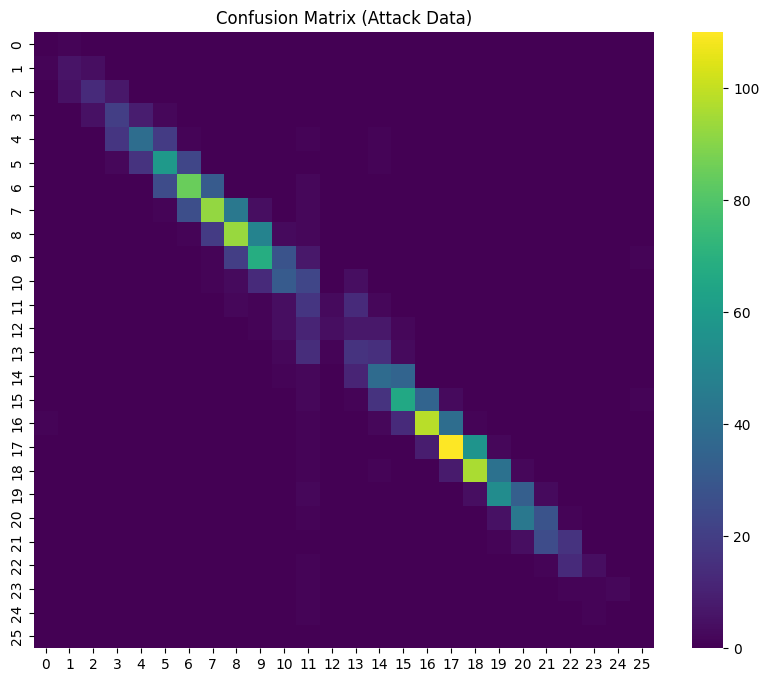

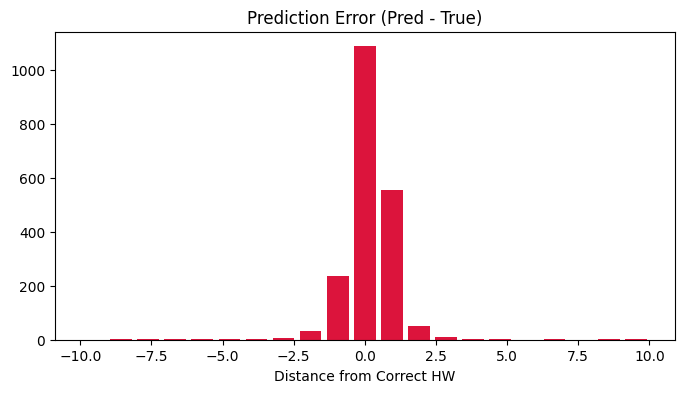

In [6]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_atk_hw, y_pred)
sns.heatmap(cm, annot=False, cmap='viridis')
plt.title('Confusion Matrix (Attack Data)')
plt.show()

errors = y_pred - y_atk_hw
plt.figure(figsize=(8, 4))
plt.hist(errors, bins=21, range=(-10, 10), rwidth=0.8, color='crimson')
plt.title('Prediction Error (Pred - True)')
plt.xlabel('Distance from Correct HW')
plt.show()